In [12]:
!pip install -q transformers datasets evaluate accelerate scikit-learn pandas matplotlib seaborn

# **Import Libraries**

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import evaluate

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

# **Load Dataset**

In [14]:
import pandas as pd

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [17]:
train_df.columns = ["label", "title", "description"]
test_df.columns = ["label", "title", "description"]

# **Check Dataset**

In [18]:
train_df.head()

,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


# **Combine Title + Description**

In [19]:
train_df["text"] = (
    train_df["title"] + " " + train_df["description"]
)

test_df["text"] = (
    test_df["title"] + " " + test_df["description"]
)

# **Convert Labels**

In [20]:
train_df = train_df[train_df["label"] != "Class Index"].copy()
test_df = test_df[test_df["label"] != "Class Index"].copy()

train_df["label"] = train_df["label"].astype(int) - 1
test_df["label"] = test_df["label"].astype(int) - 1

# **Create Text Column**

In [21]:
train_df["text"] = (
    train_df["title"].fillna("") + " " +
    train_df["description"].fillna("")
)

test_df["text"] = (
    test_df["title"].fillna("") + " " +
    test_df["description"].fillna("")
)

In [22]:
train_df.head()

,label,title,description,text
0,2,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,2,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,2,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,2,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


# **Convert to Hugging Face Dataset**

In [23]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]]
)

In [24]:
print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 120000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 7600
})


# **Now Tokenize**

In [77]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [78]:
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [79]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [80]:
# train_dataset.set_format("torch")
# test_dataset.set_format("torch")

In [81]:
print(train_dataset.column_names)
print(train_dataset[0])

['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask']
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2, '__index_level_0__': 1, 'input_ids': [101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 1006, 26665, 1007, 26665, 1011, 2460, 1011, 19041, 1010, 2813, 2395, 1005, 1055, 1040, 11101, 2989, 1032, 2316, 1997, 11087, 1011, 22330, 8713, 2015, 1010, 2024, 3773, 2665, 2153, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [82]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [83]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [84]:
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy.compute(predictions=predictions, references=labels)
    f1_score = f1.compute(predictions=predictions, references=labels, average="weighted")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1_score["f1"]
    }

# **Trainer**

In [85]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [86]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.187215,0.175894,0.944868,0.944895


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=7500, training_loss=0.21906834411621093, metrics={'train_runtime': 2730.5714, 'train_samples_per_second': 43.947, 'train_steps_per_second': 2.747, 'total_flos': 7893473402880000.0, 'train_loss': 0.21906834411621093, 'epoch': 1.0})

# **EVALUATION**

In [87]:
results = trainer.evaluate()
print(results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.187215,0.175894,1,0.944868,0.944895


{'eval_loss': 0.1758941262960434, 'eval_accuracy': 0.9448684210526316, 'eval_f1': 0.9448950686454424}


# **SAVE MODEL**

In [88]:
trainer.save_model("bert_ag_news_model")
tokenizer.save_pretrained("bert_ag_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_ag_news_model/tokenizer_config.json',
 'bert_ag_news_model/tokenizer.json')

# **TEST PREDICTION**

In [89]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="bert_ag_news_model",
    tokenizer="bert_ag_news_model"
)

print(classifier("Apple launches new AI chip for faster performance"))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'LABEL_3', 'score': 0.9875745177268982}]


In [90]:
results = trainer.evaluate()
print("Evaluation Results:")
print(results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.187215,0.175894,1,0.944868,0.944895


Evaluation Results:
{'eval_loss': 0.1758941262960434, 'eval_accuracy': 0.9448684210526316, 'eval_f1': 0.9448950686454424}


# **Predictions on Test Set**

In [91]:
pred_output = trainer.predict(test_dataset)

y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids

# **Accuracy & F1 Score (Final Report)**

In [92]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred, average="weighted"))

Accuracy: 0.9448684210526316
F1 Score: 0.9448950686454424


# **Confusion Matrix**

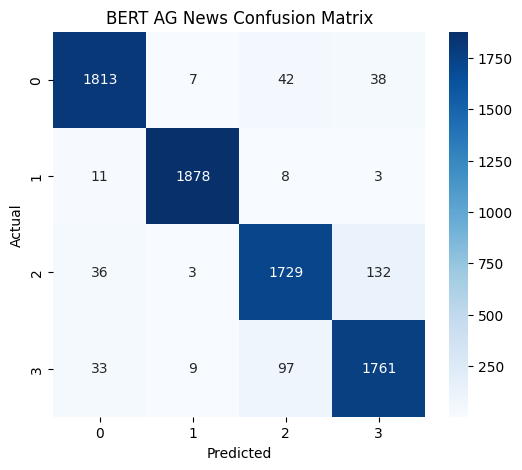

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("BERT AG News Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **Save Predictions**

In [94]:
import pandas as pd

df = pd.DataFrame({
    "text": test_df["text"].values,
    "true_label": y_true,
    "predicted_label": y_pred
})

df.to_csv("bert_agnews_predictions.csv", index=False)

# **Save Model**

In [95]:
trainer.save_model("bert_ag_news_model")
tokenizer.save_pretrained("bert_ag_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_ag_news_model/tokenizer_config.json',
 'bert_ag_news_model/tokenizer.json')

# **Test on New News**

In [96]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="bert_ag_news_model",
    tokenizer="bert_ag_news_model"
)

text = "Google introduces a new AI-powered search engine for faster results"

print(classifier(text))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'LABEL_3', 'score': 0.9722541570663452}]


# **Classification Report**

In [97]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1900
           1       0.99      0.99      0.99      1900
           2       0.92      0.91      0.92      1900
           3       0.91      0.93      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



In [98]:
trainer.save_model("bert_ag_news_model")
tokenizer.save_pretrained("bert_ag_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_ag_news_model/tokenizer_config.json',
 'bert_ag_news_model/tokenizer.json')

In [99]:
import pandas as pd

df = pd.DataFrame({
    "text": test_df["text"].values,
    "true_label": y_true,
    "predicted_label": y_pred
})

df.to_csv("bert_agnews_predictions.csv", index=False)